# **Random Forest Classifier**

---
<br>

## What is Random Forest Classifier ?
- A supervised machine learning algorithm for **classification**.
- Combines multiple **decision trees** to improve accuracy (an ensemble method).

<br>

---

<br>

## How it Works:
1. **Creates Multiple Trees**:
   - Trains on random subsets of data (bagging) and features.
2. **Voting**:
   - Each tree votes for a class, and the majority vote is the final prediction.

<br>

---

<br>

## Advantages:
- **Accurate**: Reduces overfitting compared to a single tree.
- **Robust**: Handles noisy data and missing values well.
- **Feature Importance**: Identifies important features.


<br>

## Disadvantages:
- **Slow**: Training and prediction can be time-consuming for large datasets.
- **Less Interpretable**: Hard to understand compared to a single tree.

<br>

---

<br>

## Use Cases:
- **Fraud Detection**
- **Medical Diagnosis**
- **Image/Text Classification**

<br>

---
<br>

## Overview:
Random Forest is a simple, powerful, and reliable classifier that balances accuracy and overfitting using multiple decision trees.

<br>

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv('/content/61_titanic_data.csv')

## **EDA & FEATURE ENGINEERING**

In [3]:
# Q1) what is the overall survival rate
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [4]:
# We can get in percentage by using normalize = True
df['Survived'].value_counts(normalize = True)

,proportion
Survived,
0,0.616162
1,0.383838


<Axes: xlabel='Sex', ylabel='count'>

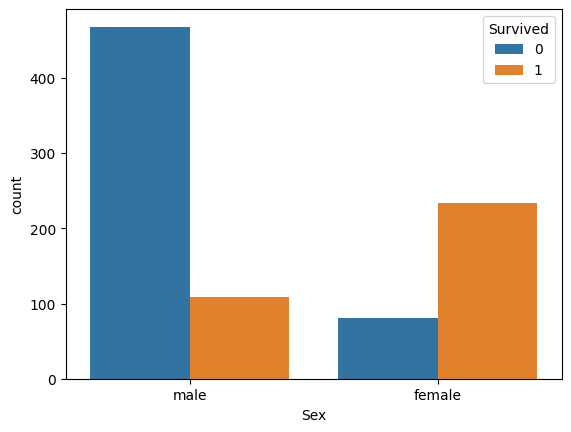

In [5]:
# Q2) Survival rate based on gender
sns.countplot(data = df, x = 'Sex', hue = 'Survived')

<Axes: xlabel='Pclass', ylabel='count'>

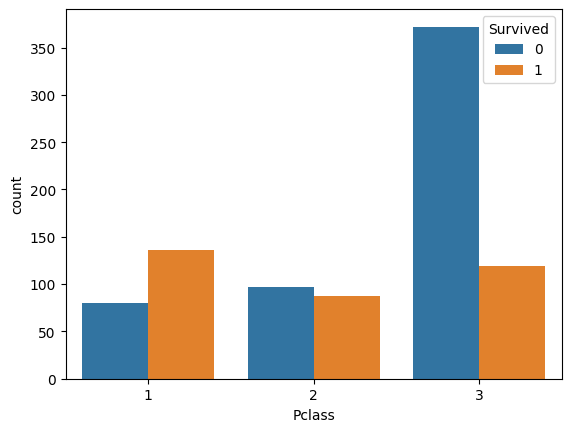

In [6]:
# Q3) Survival rate across different classes (P class)
sns.countplot(data = df, x = 'Pclass', hue = 'Survived')

In [7]:
df1 = df

In [8]:
df2 = df1.dropna(subset=['Age'])

<Axes: xlabel='Age', ylabel='Count'>

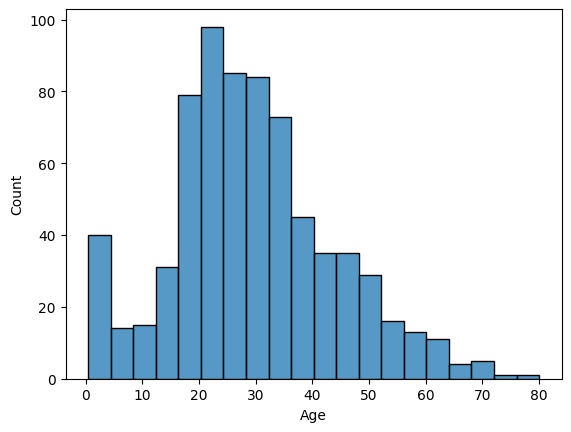

In [9]:
# Q4) what is the age distribution of passengers
sns.histplot(df2['Age'])

<Axes: xlabel='Fare', ylabel='count'>

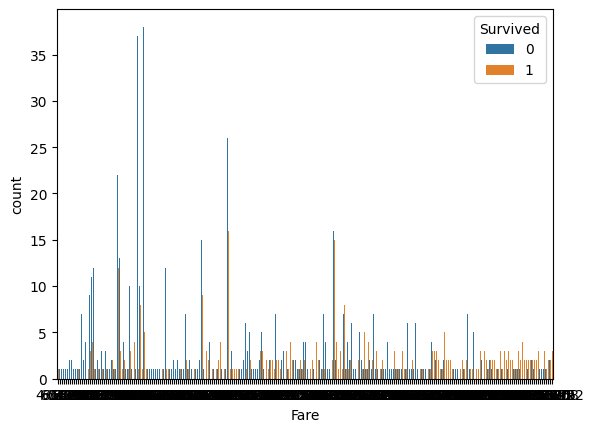

In [10]:
# Q5) does price has a correlation with survival rate
sns.countplot(data = df, x = 'Fare', hue = 'Survived')

In [11]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
df.drop('Cabin', axis = 1, inplace = True)

In [14]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
df = df.dropna(subset=['Embarked'])

In [17]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: xlabel='Age', ylabel='Count'>

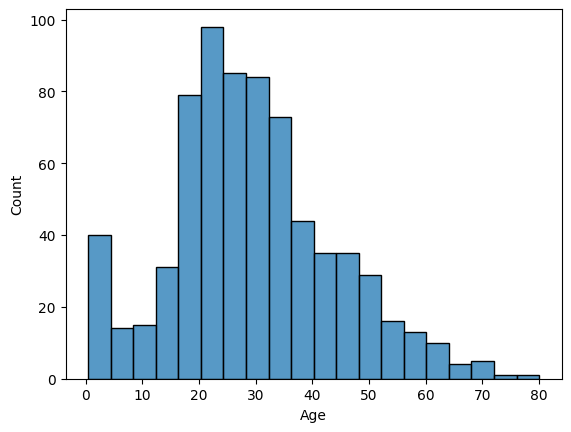

In [18]:
sns.histplot(df['Age'])

In [19]:
data = pd.get_dummies(df,columns = ['Sex'], drop_first=True, dtype = 'int')

In [20]:
X = data.drop(['Name', 'Age', 'PassengerId', 'Survived', 'Ticket', 'Fare', 'Embarked'], axis = 1)
y = data['Survived']

In [21]:
X

,Pclass,SibSp,Parch,Sex_male
0,3,1,0,1
1,1,1,0,0
2,3,0,0,0
3,1,1,0,0
4,3,0,0,1
...,...,...,...,...
886,2,0,0,1
887,1,0,0,0
888,3,1,2,0
889,1,0,0,1


In [22]:
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Random Forest Classifier**

In [24]:
# Initialize the Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [25]:
# Train the classifier
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [26]:
# Predict on the test set
y_pred = rf_classifier.predict(X_test)

In [27]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 74.72%


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.83      0.79       101
           1       0.74      0.64      0.69        77

    accuracy                           0.75       178
   macro avg       0.75      0.73      0.74       178
weighted avg       0.75      0.75      0.74       178



In [29]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

In [30]:
print(conf_matrix)

[[84 17]
 [28 49]]
